# 01 — Análise Exploratória dos Dados

**Tech Challenge — Fase 1** · Classificação de tumores de mama (maligno vs. benigno)

Base: **Breast Cancer Wisconsin (Diagnostic)** — características morfológicas de núcleos celulares
extraídas de imagens de punção aspirativa por agulha fina (PAAF).

Objetivo deste notebook: entender a base antes de qualquer modelagem — o que cada variável mede,
como as classes se distribuem, quais medidas separam tumores malignos de benignos e quais
características dos dados vão condicionar o pré-processamento.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` ao rodar o notebook a partir de notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src import config, eda
from src.data import clean, load_raw, split_features_target

eda.apply_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

---
## 1. Carregamento e primeira inspeção

In [2]:
raw = load_raw()
print(f"Formato do arquivo original: {raw.shape[0]} linhas x {raw.shape[1]} colunas")
raw.head()

Formato do arquivo original: 569 linhas x 33 colunas


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# O cabeçalho do CSV termina em vírgula, o que faz o pandas criar uma coluna extra vazia.
colunas_fantasma = [col for col in raw.columns if str(col).startswith("Unnamed")]
print("Colunas sem nome encontradas:", colunas_fantasma)
print("Valores não nulos nessas colunas:", int(raw[colunas_fantasma].notna().sum().sum()))
print()
print("Valores ausentes nas demais colunas:", int(raw.drop(columns=colunas_fantasma).isna().sum().sum()))

Colunas sem nome encontradas: ['Unnamed: 32']
Valores não nulos nessas colunas: 0

Valores ausentes nas demais colunas: 0


**Discussão.** A base tem 569 registros e nenhum valor ausente real. A única inconsistência é
estrutural: uma vírgula sobrando no cabeçalho do arquivo gera a coluna `Unnamed: 32`, inteiramente
nula. É um artefato do arquivo, não um dado faltante — descartar é o tratamento correto, e não
uma imputação.

A coluna `id` também sai: é identificador do paciente, não tem relação causal com o diagnóstico e,
se mantida, o modelo poderia aprender ruído associado à ordem de coleta.

A variável alvo `diagnosis` é categórica (`M`/`B`) e precisa ser convertida para numérica.
Codificamos **M = 1** e **B = 0**: maligno é a classe positiva, porque é o evento que se quer
detectar e cujo erro tem maior custo clínico.

In [4]:
dados = clean(raw)
X, y = split_features_target(dados)

print(f"Base limpa: {X.shape[0]} amostras x {X.shape[1]} features")
print(f"Alvo codificado: {dict(y.value_counts().sort_index())}  (0 = Benigno, 1 = Maligno)")
print()
print("As 30 features são 10 medidas do núcleo celular em 3 variantes:")
for grupo, descricao in [
    ("mean", "média das células da amostra"),
    ("se", "erro padrão da medida"),
    ("worst", "média das três piores (maiores) células"),
]:
    print(f"  _{grupo:<5} ({descricao}): {len(eda.feature_group(X, grupo))} features")

Base limpa: 569 amostras x 30 features
Alvo codificado: {0: np.int64(357), 1: np.int64(212)}  (0 = Benigno, 1 = Maligno)

As 30 features são 10 medidas do núcleo celular em 3 variantes:
  _mean  (média das células da amostra): 10 features
  _se    (erro padrão da medida): 10 features
  _worst (média das três piores (maiores) células): 10 features


---
## 2. Distribuição das classes

,classe,amostras,proporcao
0,Benigno,357,0.6274
1,Maligno,212,0.3726


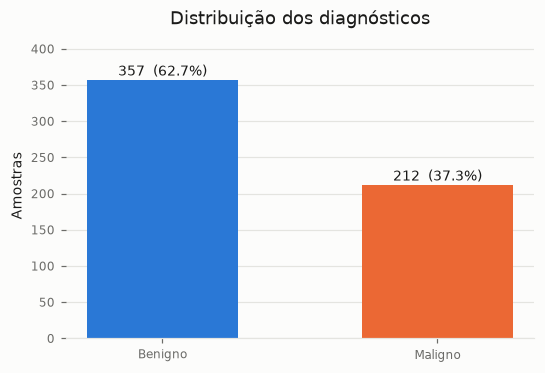

In [5]:
balanceamento = eda.class_balance(y)
display(balanceamento)
eda.plot_class_balance(y);

**Discussão.** A base tem 357 casos benignos (62,7%) e 212 malignos (37,3%). O desbalanceamento é
leve — não exige reamostragem — mas tem duas consequências práticas:

1. **A acurácia engana.** Um classificador que respondesse "benigno" para todo mundo já acertaria
   62,7%. Esse é o piso contra o qual qualquer resultado deve ser comparado.
2. **A divisão treino/teste precisa ser estratificada**, para que a proporção das classes seja
   preservada nos dois conjuntos e o teste continue representativo.

---
## 3. Estatísticas descritivas

In [6]:
estatisticas = eda.descriptive_stats(X)
display(estatisticas)

,mean,std,min,50%,max,range,skew
radius_mean,14.1273,3.5240,6.9810,13.3700,28.1100,21.1290,0.9424
texture_mean,19.2896,4.3010,9.7100,18.8400,39.2800,29.5700,0.6504
perimeter_mean,91.9690,24.2990,43.7900,86.2400,188.5000,144.7100,0.9907
area_mean,654.8891,351.9141,143.5000,551.1000,2501.0000,2357.5000,1.6457
smoothness_mean,0.0964,0.0141,0.0526,0.0959,0.1634,0.1108,0.4563
compactness_mean,0.1043,0.0528,0.0194,0.0926,0.3454,0.3260,1.1901
concavity_mean,0.0888,0.0797,0.0000,0.0615,0.4268,0.4268,1.4012
concave points_mean,0.0489,0.0388,0.0000,0.0335,0.2012,0.2012,1.1712
symmetry_mean,0.1812,0.0274,0.1060,0.1792,0.3040,0.1980,0.7256
fractal_dimension_mean,0.0628,0.0071,0.0500,0.0615,0.0974,0.0475,1.3045


In [7]:
print("Amplitude (max - min) das features, ordenada:")
display(estatisticas["range"].sort_values(ascending=False).head(5).to_frame("amplitude"))
display(estatisticas["range"].sort_values().head(5).to_frame("amplitude"))

print("\nFeatures mais assimétricas (skew):")
display(estatisticas["skew"].sort_values(ascending=False).head(5).to_frame("skew"))

Amplitude (max - min) das features, ordenada:


,amplitude
area_worst,4068.800
area_mean,2357.500
area_se,535.398
perimeter_worst,200.790
perimeter_mean,144.710


,amplitude
fractal_dimension_se,0.0289
smoothness_se,0.0294
fractal_dimension_mean,0.0475
concave points_se,0.0528
symmetry_se,0.0711



Features mais assimétricas (skew):


,skew
area_se,5.4472
concavity_se,5.1105
fractal_dimension_se,3.9240
perimeter_se,3.4436
radius_se,3.0886


**Discussão.** Duas características das features condicionam todo o pré-processamento:

- **Escalas radicalmente diferentes.** `area_worst` varia por milhares de unidades, enquanto
  `fractal_dimension_se` varia por centésimos — uma diferença de cerca de cinco ordens de grandeza.
  Algoritmos baseados em distância (KNN) ou em otimização com regularização (regressão logística)
  seriam dominados pelas variáveis de maior magnitude. **Padronização é obrigatória**, e precisa
  ficar dentro do pipeline para ser ajustada apenas com dados de treino.
- **Assimetria à direita.** Várias features, principalmente as do grupo `_se`, têm cauda longa à
  direita: a maioria das amostras concentrada em valores baixos e poucos casos com valores muito
  altos. Isso é esperado em medidas biológicas de tamanho e irregularidade, e é justamente onde
  moram os casos malignos mais severos.

---
## 4. Distribuições por diagnóstico

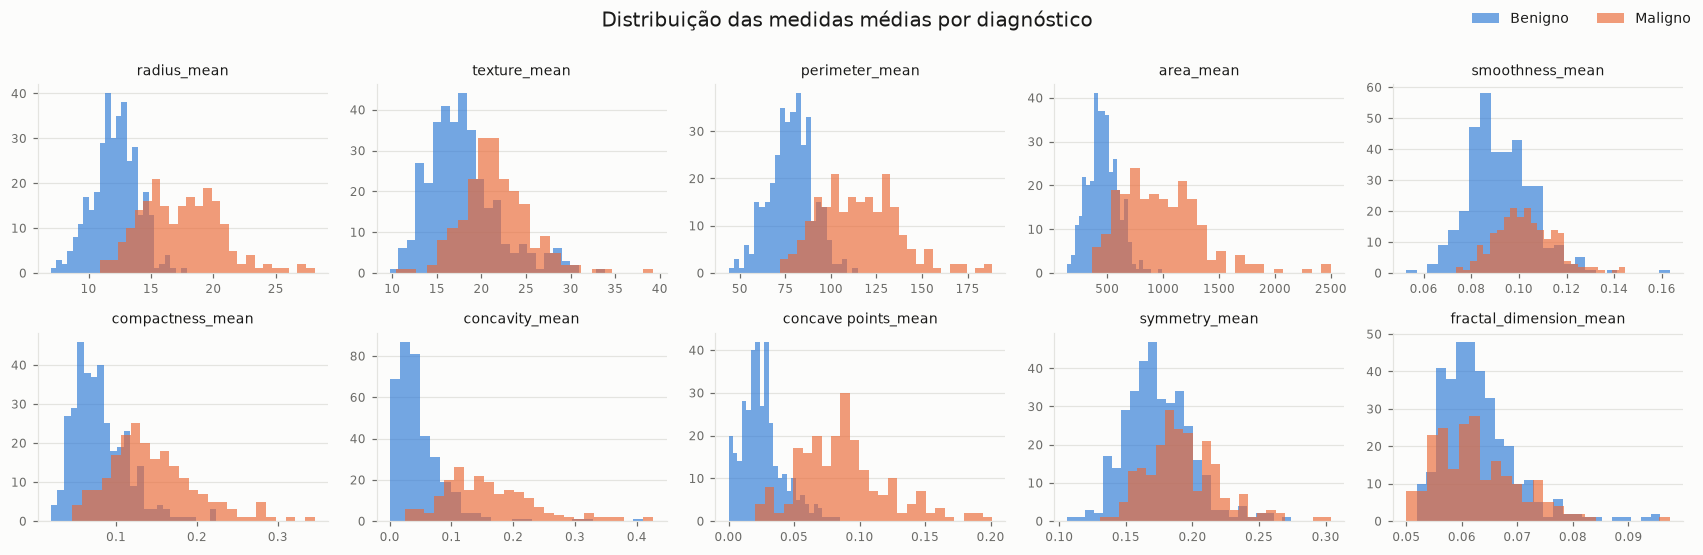

In [8]:
eda.plot_feature_distributions(
    X, y,
    features=eda.feature_group(X, "mean"),
    filename="02_distribuicoes_mean.png",
    title="Distribuição das medidas médias por diagnóstico",
);

**Discussão.** As distribuições das duas classes se separam visivelmente em boa parte das medidas
de tamanho e de irregularidade — `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean` e
`concave points_mean` mostram tumores malignos deslocados para valores mais altos, com sobreposição
parcial.

Já `smoothness_mean`, `symmetry_mean` e `fractal_dimension_mean` têm distribuições quase
sobrepostas: isoladamente, quase não distinguem os grupos. Isso é um primeiro indício de que nem
todas as 30 features carregam informação equivalente — algo que a análise de importância na Fase 5
vai confirmar quantitativamente.

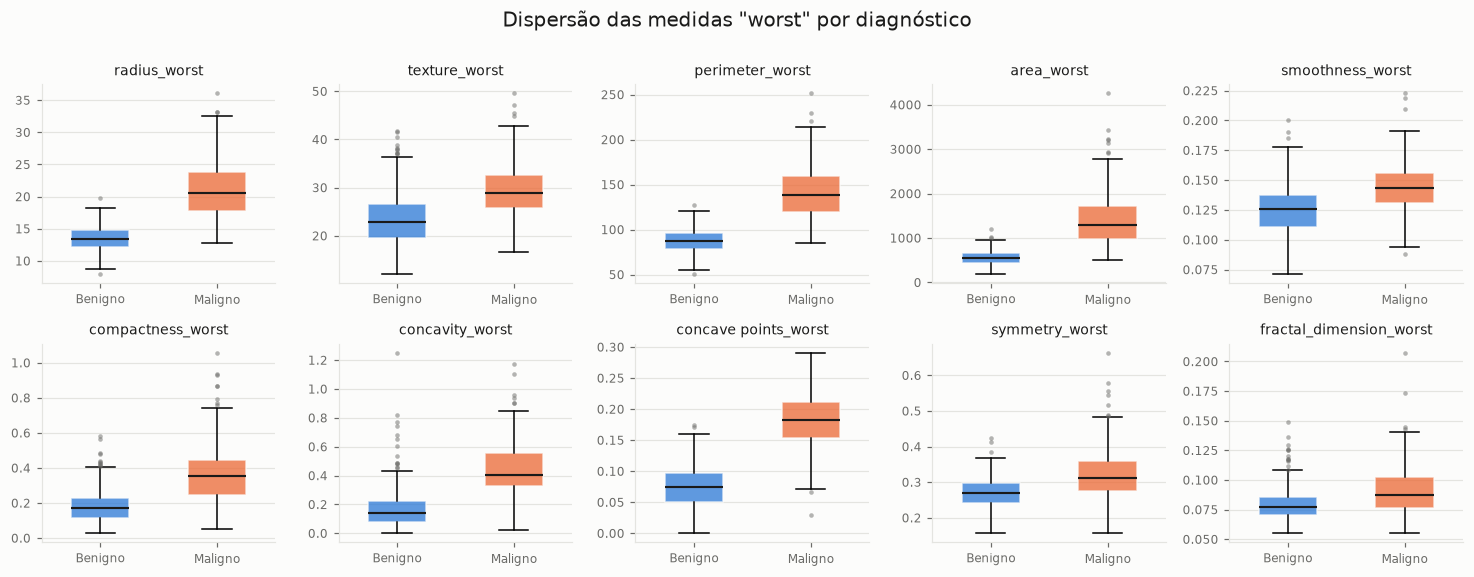

In [9]:
eda.plot_boxplots_by_class(
    X, y,
    features=eda.feature_group(X, "worst"),
    filename="03_boxplots_worst.png",
    title='Dispersão das medidas "worst" por diagnóstico',
);

**Discussão.** O grupo `_worst` (média das três piores células de cada amostra) separa as classes
com ainda mais nitidez que o grupo `_mean`. Faz sentido clínico: o que caracteriza malignidade não
é o comportamento médio do tecido, mas a existência de células com morfologia mais agressiva. A
"pior" célula da amostra é mais informativa que a célula típica.

Os pontos fora dos bigodes são numerosos, mas **não são erros de medição**: são casos extremos
reais, concentrados sobretudo na classe maligna. Removê-los descartaria justamente os casos mais
graves — exatamente os que o modelo precisa acertar. Nenhum outlier é removido neste projeto.

---
## 5. Quais medidas separam maligno de benigno

,feature,media_benigno,media_maligno,cohens_d
0,concave points_worst,0.0744,0.1822,2.693
1,perimeter_worst,87.0059,141.3703,2.598
2,concave points_mean,0.0257,0.0880,2.545
3,radius_worst,13.3798,21.1348,2.544
4,perimeter_mean,78.0754,115.3654,2.290
5,area_worst,558.8994,1422.2863,2.230
6,radius_mean,12.1465,17.4628,2.205
7,area_mean,462.7902,978.3764,2.076
8,concavity_mean,0.0461,0.1608,2.003
9,concavity_worst,0.1662,0.4506,1.812


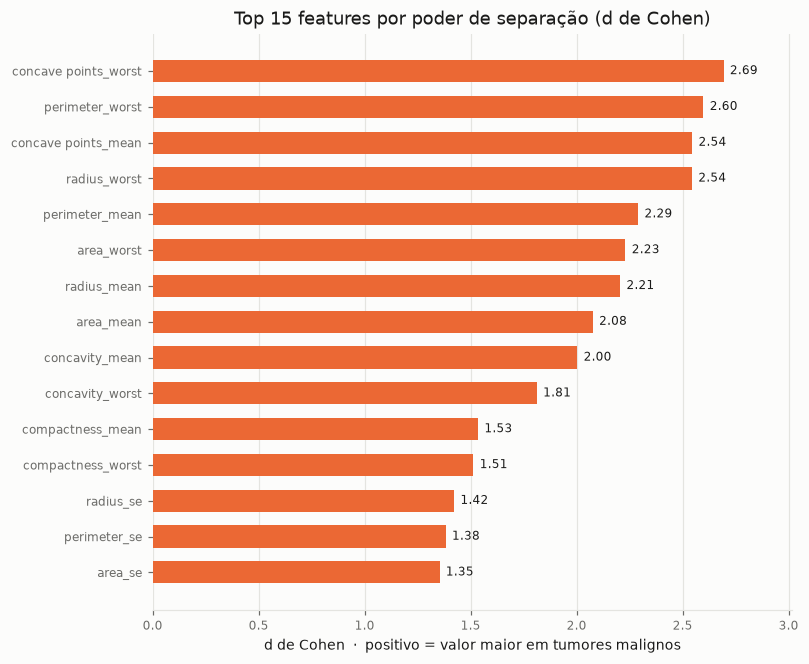

In [10]:
ranking = eda.separation_ranking(X, y)
display(ranking.head(12))
eda.plot_separation_ranking(X, y);

**Discussão.** O *d* de Cohen mede a distância entre as médias das duas classes em unidades de
desvio padrão. Por ser adimensional, permite comparar features de escalas muito diferentes. Valores
acima de 0,8 já indicam efeito grande; aqui, as primeiras colocadas passam de 2,5.

O padrão que emerge é consistente e clinicamente interpretável:

- **Concavidade e pontos côncavos** (`concave points_worst`, `concave points_mean`) lideram o
  ranking. Medem o quanto o contorno do núcleo é irregular e reentrante — a assinatura morfológica
  clássica de células malignas.
- **Medidas de tamanho** (`perimeter_worst`, `radius_worst`, `area_worst`) vêm logo em seguida:
  núcleos malignos são maiores.
- **Todos os *d* de Cohen do topo são positivos**, ou seja, os valores são sistematicamente
  maiores nos tumores malignos. Não há inversão de sinal entre as principais features.
- As medidas de **textura, simetria e dimensão fractal** ficam no fim do ranking, com poder de
  separação fraco isoladamente — o que não impede que contribuam em combinação com as demais.

Vale notar que tamanho e contorno são geometricamente relacionados: raio, perímetro e área medem
essencialmente a mesma coisa. Isso antecipa uma multicolinearidade forte, quantificada na Fase 3.

---
## Conclusões da análise exploratória

| Achado | Consequência para as próximas fases |
|---|---|
| Nenhum valor ausente real; só uma coluna fantasma do CSV | Limpeza estrutural, sem imputação |
| `id` é identificador sem valor preditivo | Removida |
| Alvo categórico `M`/`B` | Codificado como M = 1 (classe positiva) e B = 0 |
| 62,7% benignos / 37,3% malignos | Acurácia isolada não serve; split estratificado |
| Escalas com até cinco ordens de grandeza de diferença | `StandardScaler` dentro do pipeline |
| Assimetria à direita, muitos outliers legítimos | Outliers preservados: são os casos graves |
| Grupo `_worst` separa melhor que `_mean` | Sinal esperado; confirmado na importância dos modelos |
| Concavidade e tamanho lideram a separação | Coerente com a morfologia de células malignas |
| Raio, perímetro e área medem a mesma geometria | Multicolinearidade a ser analisada na Fase 3 |

**Próximo passo:** notebook 02 — pré-processamento, análise de correlação, modelagem e avaliação.